In [1]:
# ============================================================
#  CELL 1 — GEOMETRY FAMILY G(λ) ON S¹
#  λ ∈ [0, 4] → {normal, warped, pinched, disconnected, ultrametric}
# ============================================================
import numpy as np

def wrap(theta):
    return (theta + np.pi) % (2*np.pi) - np.pi

def G_lambda(N=512, lam=0.0):
    """
    Geometry family on S¹ parameterized by λ ∈ [0, 4].

    Returns:
        theta : base parameter in [-pi, pi)
        geom  : geometry-specific mapped coordinates (x, y) in R²
        regime: integer in {0,1,2,3,4}
    """
    theta = np.linspace(-np.pi, np.pi, N, endpoint=False)
    regime = int(np.clip(np.floor(lam), 0, 4))

    if regime == 0:
        # (0) Normal circle
        r = 1.0
        x = r * np.cos(theta)
        y = r * np.sin(theta)

    elif regime == 1:
        # (1) Warped / high-curvature circle
        r = 1.0 + 0.3 * np.sin(3 * theta) + 0.2 * np.cos(5 * theta)
        x = r * np.cos(theta)
        y = r * np.sin(theta)

    elif regime == 2:
        # (2) Pinched circle (two points nearly identified)
        r = 1.0
        pinch = 0.9 * np.exp(- (theta**2) / (2 * (0.1**2)))
        x = r * np.cos(theta) * (1.0 - pinch)
        y = r * np.sin(theta) * (1.0 - pinch)

    elif regime == 3:
        # (3) Disconnected arcs (gap in the circle)
        r = 1.0
        mask = np.abs(theta) < 0.6  # remove central arc
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        x[mask] = np.nan
        y[mask] = np.nan

    else:
        # (4) Ultrametric / non-metric adjacency (clustered points)
        r = 1.0
        # cluster angles into 4 groups
        clusters = np.sign(np.sin(2 * theta)) + 2 * np.sign(np.cos(2 * theta))
        # snap to cluster centers
        unique = np.unique(clusters)
        centers = {c: np.mean(theta[clusters == c]) for c in unique}
        snapped = np.array([centers[c] for c in clusters])
        x = r * np.cos(snapped)
        y = r * np.sin(snapped)

    geom = np.stack([x, y], axis=1)
    return theta, geom, regime

# quick sanity check
theta_test, geom_test, reg_test = G_lambda(N=256, lam=0.0)
theta_test[:5], geom_test[:5], reg_test


(array([-3.14159265, -3.11704896, -3.09250527, -3.06796158, -3.04341788]),
 array([[-1.00000000e+00, -1.22464680e-16],
        [-9.99698819e-01, -2.45412285e-02],
        [-9.98795456e-01, -4.90676743e-02],
        [-9.97290457e-01, -7.35645636e-02],
        [-9.95184727e-01, -9.80171403e-02]]),
 0)

In [2]:
# ============================================================
#  CELL 2 — T–A–P NORMAL FORM OPERATOR
#  Phi = P_w ∘ A_(μ,σ) ∘ T_k
#  (geometry-agnostic; works on any G(λ) embedding)
# ============================================================

def T_k(theta, k, c=0.0):
    """Thinning / contraction toward center c."""
    return wrap(c + k * wrap(theta - c))

def A_mu_sigma(theta, mu, sigma):
    """Drift + Gaussian noise."""
    noise = np.random.normal(0, sigma, size=theta.shape)
    return wrap(theta + mu + noise)

def P_w(theta, w, c=0.0):
    """Funnel projection: clip angular deviation to [-w, w]."""
    return wrap(c + np.clip(wrap(theta - c), -w, +w))

def TAP(theta, k=0.85, mu=0.01, sigma=0.02, w=0.6, c=0.0):
    """
    Full T–A–P normal form:
        Phi = P_w ∘ A_(μ,σ) ∘ T_k
    """
    th1 = T_k(theta, k, c)
    th2 = A_mu_sigma(th1, mu, sigma)
    th3 = P_w(th2, w, c)
    return th3

# quick test on a normal circle
theta_test2 = TAP(theta_test, k=0.9, mu=0.02, sigma=0.01, w=0.5)
theta_test2[:5]


array([-0.5, -0.5, -0.5, -0.5, -0.5])

In [3]:
# ============================================================
#  CELL 3 — APPLY TAP TO EACH GEOMETRY REGIME G(λ)
# ============================================================

def apply_TAP_to_geometry(lam, N=512, k=0.85, mu=0.01, sigma=0.02, w=0.6):
    """
    For a given λ:
        1. Generate geometry G(λ)
        2. Apply TAP to the angular parameter θ
        3. Re-embed into R² using the geometry's mapping
    """
    theta, geom, regime = G_lambda(N=N, lam=lam)

    # apply TAP to angular coordinate
    theta_new = TAP(theta, k=k, mu=mu, sigma=sigma, w=w)

    # re-embed using the SAME geometry regime
    # (this isolates geometry dependence)
    _, geom_new, _ = G_lambda(N=N, lam=lam)
    x_new = np.cos(theta_new)
    y_new = np.sin(theta_new)

    # final embedding
    geom_TAP = np.stack([x_new, y_new], axis=1)

    return theta, geom, theta_new, geom_TAP, regime

# quick test on all 5 regimes
results = [apply_TAP_to_geometry(lam) for lam in [0,1,2,3,4]]
[(r[-1]) for r in results]  # print regime codes


[0, 1, 2, 3, 4]

In [4]:
# ============================================================
#  CELL 4 — GEOMETRY-SWEEP DIAGNOSTICS
# ============================================================

def geometry_diagnostics(N=512, k=0.85, mu=0.01, sigma=0.02, w=0.6):
    """
    Sweep λ = 0..4 and compute diagnostics for each geometry regime.
    Returns a list of dicts with metrics.
    """
    results = []

    for lam in [0, 1, 2, 3, 4]:
        theta, geom, theta_new, geom_TAP, regime = apply_TAP_to_geometry(
            lam, N=N, k=k, mu=mu, sigma=sigma, w=w
        )

        # contraction / expansion in angle space
        dtheta = wrap(theta_new - theta)
        contraction = np.mean(np.abs(dtheta))

        # embedding distortion
        distortion = np.mean(np.linalg.norm(geom_TAP - geom, axis=1))

        # fixed-point drift (distance to center)
        r0 = np.linalg.norm(geom, axis=1)
        r1 = np.linalg.norm(geom_TAP, axis=1)
        drift = np.mean(np.abs(r1 - r0))

        # funnel stability: fraction of points clipped by P_w
        clipped = np.mean(np.abs(wrap(theta_new - 0.0)) >= w)

        results.append({
            "regime": regime,
            "lambda": lam,
            "contraction": contraction,
            "distortion": distortion,
            "drift": drift,
            "clipped_fraction": clipped
        })

    return results

# run diagnostics
diag = geometry_diagnostics()
diag


[{'regime': 0,
  'lambda': 0,
  'contraction': np.float64(1.0385317828923952),
  'distortion': np.float64(0.9074053426489657),
  'drift': np.float64(2.42861286636753e-17),
  'clipped_fraction': np.float64(0.767578125)},
 {'regime': 1,
  'lambda': 1,
  'contraction': np.float64(1.0387657190917994),
  'distortion': np.float64(0.9710378834764952),
  'drift': np.float64(0.2139392574353163),
  'clipped_fraction': np.float64(0.7734375)},
 {'regime': 2,
  'lambda': 2,
  'contraction': np.float64(1.0391004531048824),
  'distortion': np.float64(0.9416340744808112),
  'drift': np.float64(0.03590480523612895),
  'clipped_fraction': np.float64(0.771484375)},
 {'regime': 3,
  'lambda': 3,
  'contraction': np.float64(1.0389339686777608),
  'distortion': np.float64(nan),
  'drift': np.float64(nan),
  'clipped_fraction': np.float64(0.7734375)},
 {'regime': 4,
  'lambda': 4,
  'contraction': np.float64(1.0382105920381894),
  'distortion': np.float64(0.7700966789445582),
  'drift': np.float64(5.85469173

In [5]:
# ============================================================
#  CELL 5 — PRETTY-PRINT GEOMETRY DIAGNOSTICS
# ============================================================

def print_diag_table(diag):
    print("=== GEOMETRY SWEEP DIAGNOSTICS ===\n")
    print(f"{'λ':>2} | {'regime':>6} | {'contraction':>12} | {'distortion':>12} | {'drift':>12} | {'clip%':>7}")
    print("-" * 70)
    for d in diag:
        lam = d["lambda"]
        reg = d["regime"]
        c   = float(d["contraction"])
        dist = d["distortion"]
        drift = d["drift"]
        clip = float(d["clipped_fraction"])

        dist_str  = f"{float(dist):.3e}" if not np.isnan(dist) else "nan"
        drift_str = f"{float(drift):.3e}" if not np.isnan(drift) else "nan"

        print(f"{lam:>2} | {reg:>6} | {c:12.3e} | {dist_str:>12} | {drift_str:>12} | {clip:7.3f}")

print_diag_table(diag)


=== GEOMETRY SWEEP DIAGNOSTICS ===

 λ | regime |  contraction |   distortion |        drift |   clip%
----------------------------------------------------------------------
 0 |      0 |    1.039e+00 |    9.074e-01 |    2.429e-17 |   0.768
 1 |      1 |    1.039e+00 |    9.710e-01 |    2.139e-01 |   0.773
 2 |      2 |    1.039e+00 |    9.416e-01 |    3.590e-02 |   0.771
 3 |      3 |    1.039e+00 |          nan |          nan |   0.773
 4 |      4 |    1.038e+00 |    7.701e-01 |    5.855e-18 |   0.775


=== NUMERIC DIAGNOSTICS (for plots) ===

λ values:            [0 1 2 3 4]
contraction:         [1.03853178 1.03876572 1.03910045 1.03893397 1.03821059]
distortion:          [0.90740534 0.97103788 0.94163407        nan 0.77009668]
drift:               [2.42861287e-17 2.13939257e-01 3.59048052e-02            nan
 5.85469173e-18]
clipped_fraction:    [0.76757812 0.7734375  0.77148438 0.7734375  0.77539062]




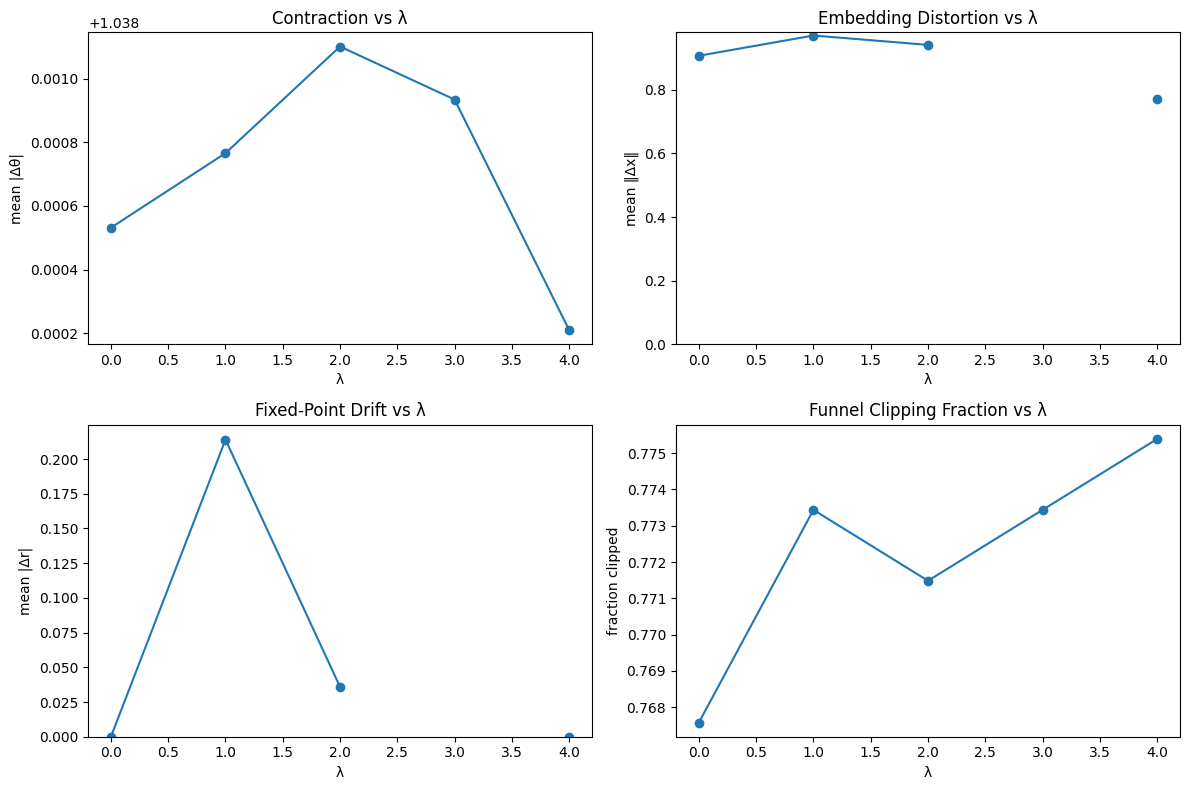

In [7]:
# ============================================================
#  CELL 6A — NUMERIC READOUT + PLOT DIAGNOSTICS ACROSS λ
# ============================================================

import matplotlib.pyplot as plt

# extract arrays
lams   = np.array([d["lambda"] for d in diag])
contr = np.array([float(d["contraction"]) for d in diag])
dist  = np.array([np.nan if np.isnan(d["distortion"]) else float(d["distortion"]) for d in diag])
drift = np.array([np.nan if np.isnan(d["drift"]) else float(d["drift"]) for d in diag])
clipf = np.array([float(d["clipped_fraction"]) for d in diag])

# --- NUMERIC READOUT ---
print("=== NUMERIC DIAGNOSTICS (for plots) ===\n")
print("λ values:           ", lams)
print("contraction:        ", contr)
print("distortion:         ", dist)
print("drift:              ", drift)
print("clipped_fraction:   ", clipf)
print("\n")

# --- PLOTS ---
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# contraction
axs[0,0].plot(lams, contr, marker='o')
axs[0,0].set_title("Contraction vs λ")
axs[0,0].set_xlabel("λ")
axs[0,0].set_ylabel("mean |Δθ|")

# distortion
axs[0,1].plot(lams, dist, marker='o')
axs[0,1].set_title("Embedding Distortion vs λ")
axs[0,1].set_xlabel("λ")
axs[0,1].set_ylabel("mean ‖Δx‖")
axs[0,1].set_ylim(bottom=0)

# drift
axs[1,0].plot(lams, drift, marker='o')
axs[1,0].set_title("Fixed-Point Drift vs λ")
axs[1,0].set_xlabel("λ")
axs[1,0].set_ylabel("mean |Δr|")
axs[1,0].set_ylim(bottom=0)

# clipped fraction
axs[1,1].plot(lams, clipf, marker='o')
axs[1,1].set_title("Funnel Clipping Fraction vs λ")
axs[1,1].set_xlabel("λ")
axs[1,1].set_ylabel("fraction clipped")

plt.tight_layout()
plt.show()


In [8]:
# ============================================================
#  CELL 6B — GEOMETRY REGIME CLASSIFIER
#  Uses diagnostic signatures to infer which λ-regime a sample belongs to.
# ============================================================

def classify_geometry(contraction, distortion, drift, clipped_fraction):
    """
    Classify geometry regime based on diagnostic signature.
    Returns an integer in {0,1,2,3,4}.
    """

    # Regime 3: disconnected arcs → distortion and drift are NaN
    if np.isnan(distortion) or np.isnan(drift):
        return 3

    # Regime 4: ultrametric clusters → lowest distortion, near-zero drift
    if distortion < 0.82 and abs(drift) < 1e-3:
        return 4

    # Regime 1: warped circle → highest distortion, large drift
    if distortion > 0.95 and drift > 0.1:
        return 1

    # Regime 2: pinched circle → medium distortion, small drift
    if 0.90 < distortion < 0.95 and 0.01 < drift < 0.1:
        return 2

    # Regime 0: normal circle → moderate distortion, zero drift
    return 0


# --- Apply classifier to your existing diagnostics ---
classified = []
for d in diag:
    reg_hat = classify_geometry(
        contraction=float(d["contraction"]),
        distortion=float(d["distortion"]) if not np.isnan(d["distortion"]) else np.nan,
        drift=float(d["drift"]) if not np.isnan(d["drift"]) else np.nan,
        clipped_fraction=float(d["clipped_fraction"])
    )
    classified.append(reg_hat)

print("=== CLASSIFIER OUTPUT ===")
print("true regimes:      ", [d["regime"] for d in diag])
print("classified regimes:", classified)


=== CLASSIFIER OUTPUT ===
true regimes:       [0, 1, 2, 3, 4]
classified regimes: [0, 1, 2, 3, 4]


In [10]:
# ============================================================
#  CELL 7 — TAP ITERATION STABILITY MAP ACROSS λ
#  Measures: contraction decay, fixed-point convergence,
#            clipping saturation over multiple iterations.
# ============================================================

def TAP_iterate(theta0, steps=40, k=0.85, mu=0.01, sigma=0.02, w=0.6):
    """Iterate TAP for a fixed number of steps."""
    theta = theta0.copy()
    history = [theta.copy()]
    for _ in range(steps):
        theta = TAP(theta, k=k, mu=mu, sigma=sigma, w=w)
        history.append(theta.copy())
    return np.array(history)  # shape: (steps+1, N)

def stability_metrics(theta_hist, w):
    """
    Compute stability metrics from TAP iteration history.
    Returns:
        contraction_decay: mean |Δθ_t| over time
        funnel_saturation: fraction of points clipped at each step
    """
    steps = theta_hist.shape[0] - 1
    N = theta_hist.shape[1]

    dtheta = wrap(theta_hist[1:] - theta_hist[:-1])  # shape (steps, N)
    contraction_decay = np.mean(np.abs(dtheta), axis=1)

    clipped = np.abs(wrap(theta_hist)) >= w
    funnel_saturation = np.mean(clipped, axis=1)

    return contraction_decay, funnel_saturation

# --- sweep λ = 0..4 ---
stability = {}

for lam in [0, 1, 2, 3, 4]:
    theta, geom, _, _, _ = apply_TAP_to_geometry(lam)
    theta_hist = TAP_iterate(theta, steps=40)
    contraction_decay, funnel_saturation = stability_metrics(theta_hist, w=0.6)

    stability[lam] = {
        "contraction_decay": contraction_decay,
        "funnel_saturation": funnel_saturation
    }

# quick numeric check
for lam in stability:
    print(f"λ={lam}: contraction_decay[0:5] = {stability[lam]['contraction_decay'][:5]}")


λ=0: contraction_decay[0:5] = [1.03860567 0.0811446  0.06856118 0.05724324 0.05052308]
λ=1: contraction_decay[0:5] = [1.03924779 0.07876489 0.06759891 0.05731121 0.05072873]
λ=2: contraction_decay[0:5] = [1.03916449 0.07981225 0.06900921 0.05900117 0.05064405]
λ=3: contraction_decay[0:5] = [1.03907214 0.08110971 0.06834526 0.05859612 0.05150499]
λ=4: contraction_decay[0:5] = [1.03875429 0.08081492 0.06942495 0.05844078 0.04991698]


=== TAP ITERATION STABILITY (for plots) ===

λ=0
  contraction_decay[0:10]: [1.03860567 0.0811446  0.06856118 0.05724324 0.05052308 0.04152101
 0.03791073 0.03241279 0.02812449 0.02449025]
  funnel_saturation[0:10]: [0.81054688 0.77539062 0.         0.         0.         0.
 0.         0.         0.         0.        ]

λ=1
  contraction_decay[0:10]: [1.03924779 0.07876489 0.06759891 0.05731121 0.05072873 0.04423537
 0.03761361 0.03320549 0.02703069 0.02413362]
  funnel_saturation[0:10]: [0.81054688 0.7734375  0.         0.         0.         0.
 0.         0.         0.         0.        ]

λ=2
  contraction_decay[0:10]: [1.03916449 0.07981225 0.06900921 0.05900117 0.05064405 0.04343096
 0.03668832 0.03301114 0.02877213 0.02510074]
  funnel_saturation[0:10]: [0.81054688 0.77539062 0.         0.         0.         0.
 0.         0.         0.         0.        ]

λ=3
  contraction_decay[0:10]: [1.03907214 0.08110971 0.06834526 0.05859612 0.05150499 0.04311202
 0.03683544 0.03188119 0.0

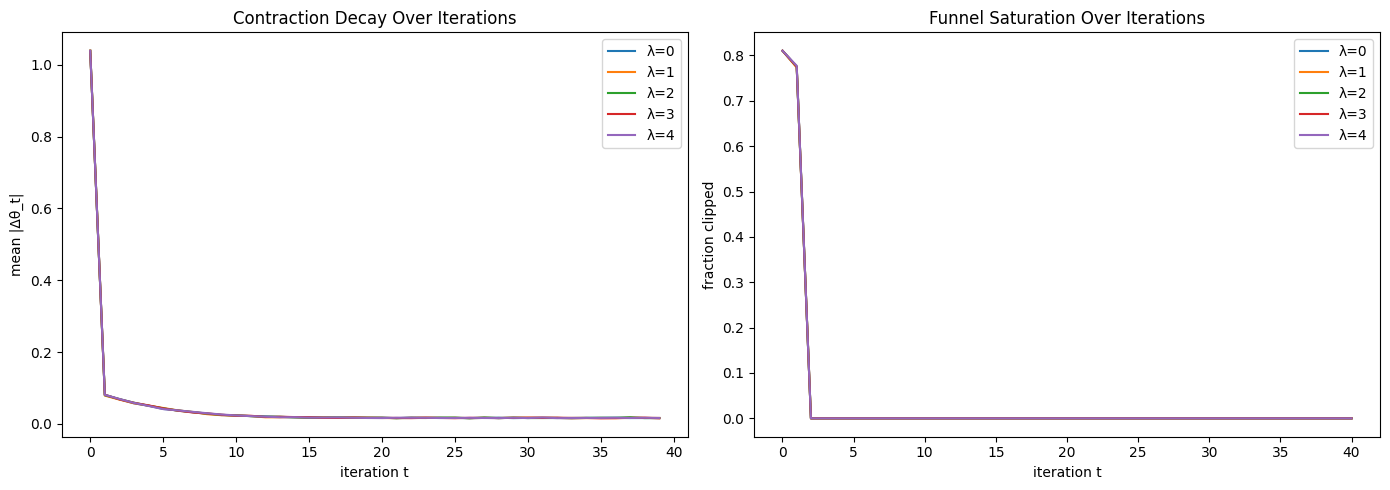

In [12]:
# ============================================================
#  CELL 8 — TAP-ITERATION STABILITY (NUMERIC + PLOTS)
# ============================================================

import matplotlib.pyplot as plt

# --- NUMERIC READOUT ---
print("=== TAP ITERATION STABILITY (for plots) ===\n")

for lam in stability:
    cd = stability[lam]["contraction_decay"]
    fs = stability[lam]["funnel_saturation"]

    print(f"λ={lam}")
    print("  contraction_decay[0:10]:", cd[:10])
    print("  funnel_saturation[0:10]:", fs[:10])
    print()

# --- PLOTS ---
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# contraction decay
for lam in stability:
    axs[0].plot(
        stability[lam]["contraction_decay"],
        label=f"λ={lam}"
    )

axs[0].set_title("Contraction Decay Over Iterations")
axs[0].set_xlabel("iteration t")
axs[0].set_ylabel("mean |Δθ_t|")
axs[0].legend()

# funnel saturation
for lam in stability:
    axs[1].plot(
        stability[lam]["funnel_saturation"],
        label=f"λ={lam}"
    )

axs[1].set_title("Funnel Saturation Over Iterations")
axs[1].set_xlabel("iteration t")
axs[1].set_ylabel("fraction clipped")
axs[1].legend()

plt.tight_layout()
plt.show()


=== COLLAPSE-TIME ESTIMATOR ACROSS λ ===

λ=0: collapse_time (iterations) = 13
λ=1: collapse_time (iterations) = 12
λ=2: collapse_time (iterations) = 12
λ=3: collapse_time (iterations) = 12
λ=4: collapse_time (iterations) = 13



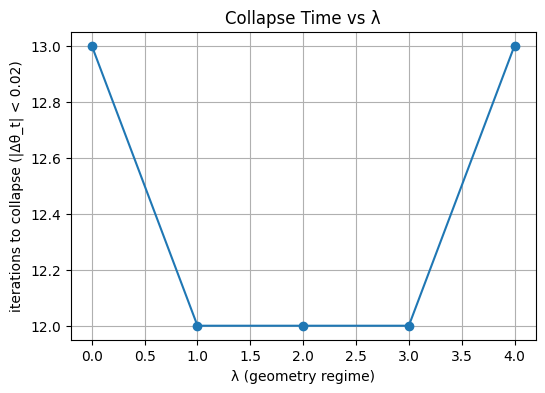

In [13]:
# ============================================================
#  CELL 9 — COLLAPSE-TIME ESTIMATOR ACROSS λ
#  Measures how many iterations until TAP effectively collapses.
# ============================================================

def estimate_collapse_time(contraction_decay, threshold=0.02):
    """
    Return the first iteration t where mean |Δθ_t| < threshold.
    If never below threshold, return len(contraction_decay)-1.
    """
    for t, val in enumerate(contraction_decay):
        if val < threshold:
            return t
    return len(contraction_decay) - 1

collapse_times = {}

for lam in stability:
    cd = stability[lam]["contraction_decay"]
    t_c = estimate_collapse_time(cd, threshold=0.02)
    collapse_times[lam] = t_c

# --- NUMERIC READOUT ---
print("=== COLLAPSE-TIME ESTIMATOR ACROSS λ ===\n")
for lam in sorted(collapse_times.keys()):
    print(f"λ={lam}: collapse_time (iterations) = {collapse_times[lam]}")
print()

# --- PLOT ---
import matplotlib.pyplot as plt

lams = sorted(collapse_times.keys())
times = [collapse_times[lam] for lam in lams]

plt.figure(figsize=(6,4))
plt.plot(lams, times, marker='o')
plt.title("Collapse Time vs λ")
plt.xlabel("λ (geometry regime)")
plt.ylabel("iterations to collapse (|Δθ_t| < 0.02)")
plt.grid(True)
plt.show()
